In [ ]:
!pip -q install transformers datasets sentence-transformers faiss-cpu tqdm scikit-learn evaluate rouge-score bert_score nltk matplotlib seaborn


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 7.6 MB/s eta 0:00:00


In [ ]:
import torch, random, numpy as np, pandas as pd, nltk, time
from nltk.tokenize.punkt import PunktSentenceTokenizer
from datasets import load_dataset
from sentence_transformers import SentenceTransformer, CrossEncoder, util
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoConfig, pipeline
from tqdm import tqdm
import evaluate
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
nltk.download('punkt', quiet=True)

True

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


**safe_sent_tokenize** tokenizes text into sentences using PunktSentenceTokenizer;

**chunk_text** splits text into overlapping chunks. Chunking helps dense retrievers find semantically coherent passages and improves retrieval precision.

In [ ]:
def safe_sent_tokenize(text):
    tokenizer = PunktSentenceTokenizer()
    return tokenizer.tokenize(text)


def chunk_text(text, chunk_size=150, overlap=50):
    words = text.split()
    chunks = []
    for i in range(0, len(words), chunk_size - overlap):
        chunks.append(" ".join(words[i:i+chunk_size]))
    return chunks

**encode_chunks_with_params** tokenizes documents into chunks and computes embeddings.
Returns:
 - chunks: all text chunks
 - chunk_to_doc: mapping from chunk index to original document
 - embeddings: tensor of embeddings;

**retrieve** retrieves relevant chunks using dense embeddings and optional cross-encoder reranking, ensuring LLM has evidence to generate factually grounded summaries.

In [ ]:
def encode_chunks_with_params(documents, chunk_size=150, overlap=50, batch_size=32):
    chunks = []
    chunk_to_doc = []
    for i, doc in enumerate(documents):
        doc_chunks = chunk_text(doc, chunk_size, overlap)
        chunks.extend(doc_chunks)
        chunk_to_doc.extend([i]*len(doc_chunks))

    embeddings_list = []
    for start in range(0, len(chunks), batch_size):
        batch = chunks[start:start+batch_size]
        try:
            emb = embed_model.encode(batch, convert_to_tensor=True, device=device)
        except RuntimeError:
            print("GPU OOM: using CPU for batch")
            emb = embed_model.encode(batch, convert_to_tensor=True, device='cpu')
        embeddings_list.append(emb)
    embeddings = torch.cat(embeddings_list)
    return chunks, chunk_to_doc, embeddings


def expand_query(query, use_expansion=True):
    return query


def retrieve(query, top_k=200, rerank_k=20, use_reranker=True, batch_size=8):
    try:
        q_emb = embed_model.encode(query, convert_to_tensor=True, device=device)
    except RuntimeError:
        q_emb = embed_model.encode(query, convert_to_tensor=True, device='cpu')
    hits = util.semantic_search(q_emb, chunk_embeddings, top_k=top_k)[0]
    retrieved = [chunks[h["corpus_id"]] for h in hits]

    if use_reranker:
        scores_list = []
        for start in range(0, len(retrieved), batch_size):
            batch_pairs = [[query, doc] for doc in retrieved[start:start+batch_size]]
            try:
                batch_scores = reranker.predict(batch_pairs)
            except RuntimeError:
                batch_scores = reranker.predict(batch_pairs, device='cpu')
            scores_list.extend(batch_scores)
        scores = np.array(scores_list)
        top_idx = np.argsort(scores)[::-1][:rerank_k]
        return [retrieved[i] for i in top_idx]
    return retrieved[:rerank_k]


**build_context** concatenates retrieved documents up to max token limit, providing LLM with sufficient evidence without exceeding memory limits;

**safe_generate** generates text with LLM and handles potential exceptions, ensuring robustness during experiments.

In [ ]:
def build_context(docs, max_tokens=1600):
    total = 0
    selected = []
    for i, doc in enumerate(docs):
        tokens = tokenizer.encode(doc)
        if total + len(tokens) > max_tokens: break
        selected.append(f"[{i}] {doc}")
        total += len(tokens)
    return "\n".join(selected)


def safe_generate(prompt, max_tokens=250):
    try:
        out = generator(prompt, max_new_tokens=max_tokens)
        if isinstance(out, list) and isinstance(out[0], dict):
            return out[0]["generated_text"]
        if isinstance(out, list): return out[0]
        return str(out)
    except: return ""


Faithfulness metrics:
1. **Sentence grounding** - semantic similarity between summary sentences and retrieved chunks
2. **Entailment score** - logical support of summary sentences by retrieved evidence
3. **Coverage** - fraction of sentences supported by retrieved context (cosine similarity threshold)

In [ ]:
def sentence_grounding(answer, docs, batch_size=16):
    sentences = safe_sent_tokenize(answer)
    if not sentences: return 0
    sent_emb_list = []
    for start in range(0, len(sentences), batch_size):
        batch = sentences[start:start+batch_size]
        try:
            emb = embed_model.encode(batch, convert_to_tensor=True, device=device)
        except RuntimeError:
            emb = embed_model.encode(batch, convert_to_tensor=True, device='cpu')
        sent_emb_list.append(emb)
    sent_emb = torch.cat(sent_emb_list)
    try:
        doc_emb = embed_model.encode(docs, convert_to_tensor=True, device=device)
    except RuntimeError:
        doc_emb = embed_model.encode(docs, convert_to_tensor=True, device='cpu')
    scores = [torch.max(util.cos_sim(s, doc_emb)).item() for s in sent_emb]
    return float(np.mean(scores))


def entailment_faithfulness(answer, docs):
    if not answer.strip(): return 0
    sentences = safe_sent_tokenize(answer)
    scores = []
    for sent in sentences:
        sent_scores = []
        for doc in docs[:3]: # use top 3 docs for efficiency
            pair = f"{doc} </s> {sent}"
            try: result = nli_model(pair)[0]; sent_scores.append(result["score"] if result["label"]=="ENTAILMENT" else 0)
            except: sent_scores.append(0)
        if sent_scores: scores.append(max(sent_scores))
    return float(np.mean(scores)) if scores else 0


def coverage(answer, docs, threshold=0.6, batch_size=16):
    sentences = safe_sent_tokenize(answer)
    if not sentences: return 0
    sent_emb_list = []
    for start in range(0, len(sentences), batch_size):
        batch = sentences[start:start+batch_size]
        try:
            emb = embed_model.encode(batch, convert_to_tensor=True, device=device)
        except RuntimeError:
            emb = embed_model.encode(batch, convert_to_tensor=True, device='cpu')
        sent_emb_list.append(emb)
    sent_emb = torch.cat(sent_emb_list)
    try:
        doc_emb = embed_model.encode(docs, convert_to_tensor=True, device=device)
    except RuntimeError:
        doc_emb = embed_model.encode(docs, convert_to_tensor=True, device='cpu')
    grounded = sum(1 for s in sent_emb if torch.max(util.cos_sim(s, doc_emb)).item() >= threshold)
    return grounded / len(sentences)


Full retrieval-augmented generation pipeline:


1. Optionally expand query
2. Retrieve top_k passages (optionally reranked)
3. Optionally filter by entailment
4. Optionally summarize hierarchically
5. Generate final answer using retrieved context

In [ ]:
def rag_answer(query, entail_filter=False, hierarchical_depth=None, top_k=200, rerank_k=20, use_expansion=True, use_reranker=True):
    query_exp = expand_query(query, use_expansion)
    docs = retrieve(query_exp, top_k=top_k, rerank_k=rerank_k, use_reranker=use_reranker)
    if entail_filter:
        filtered = [d for d in docs if nli_model(f"{d} </s> {query_exp}")[0]["label"]=="ENTAILMENT"]
        if filtered: docs = filtered
    if hierarchical_depth is not None:
        docs = [safe_generate(f"Summarize the following text:\n{d}\nSummary:") for d in docs[:hierarchical_depth]]
    context = build_context(docs)
    prompt = f"Answer using ONLY the context.\n\nContext:\n{context}\n\nQuestion: {query}\n\nAnswer:"
    return safe_generate(prompt), docs


Loading the arXiv summarization test dataset and selects a random subset of 20 documents for experimentation. Selecting a subset reduces runtime while still providing a representative sample for evaluation. documents contain the full articles, while references contain the corresponding abstracts (used as ground truth for evaluation).

In [ ]:
dataset = load_dataset("ccdv/arxiv-summarization", split="test")
NUM_DOCS = 20
subset_indices = random.sample(range(len(dataset)), NUM_DOCS)
documents = [dataset[i]["article"] for i in subset_indices]
references = [dataset[i]["abstract"] for i in subset_indices]
print("Documents loaded:", len(documents))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

section/train-00000-of-00015.parquet:   0%|          | 0.00/230M [00:00<?, ?B/s]

section/train-00001-of-00015.parquet:   0%|          | 0.00/228M [00:00<?, ?B/s]

section/train-00002-of-00015.parquet:   0%|          | 0.00/228M [00:00<?, ?B/s]

...

section/test-00000-of-00001.parquet:   0%|          | 0.00/105M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/203037 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6436 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6440 [00:00<?, ? examples/s]

Documents loaded: 20


Loading MiniLM embeddings for semantic search, and a cross-encoder reranker for refining candidate passages.

In [ ]:
embed_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=device)
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-12-v2", device=0 if device=="cuda" else -1)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

Loading Phi-2 LLM for generating summaries, with proper padding and tokenization and loading  RoBERTa-MNLI for computing entailment scores to evaluate factual consistency.

In [ ]:
model_name = "microsoft/phi-2"
config = AutoConfig.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"
config.pad_token_id = tokenizer.pad_token_id

model = AutoModelForCausalLM.from_pretrained( model_name, config=config, torch_dtype=torch.float32, device_map="auto")
generator = pipeline("text-generation", model=model, tokenizer=tokenizer, return_full_text=False, device=-1)
nli_model = pipeline("text-classification", model="roberta-large-mnli", device=-1)


config.json:   0%|          | 0.00/735 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

...

RobertaForSequenceClassification LOAD REPORT from: roberta-large-mnli
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Preparing evaluation metrics: ROUGE (overlap-based similarity with reference summaries) and BERTScore (semantic similarity). These will be used later to quantify quality of generated summaries.

**experiment_configs** defines variants of retrieval and summarization strategies (chunk size, overlap, reranking, expansion, hierarchical summarization);

**queries constructs** input prompts for the LLM, using the first 300 characters of each document to guide the summary generation.

In [ ]:
rouge = evaluate.load("rouge")
bertscore = evaluate.load("bertscore")

experiment_configs = [
    {"name":"baseline","chunk_size":150,"overlap":50,"top_k":200,"rerank_k":20,"use_expansion":True,"use_reranker":True,"hierarchical_depth":None},
    {"name":"large_chunks","chunk_size":300,"overlap":50,"top_k":200,"rerank_k":20,"use_expansion":True,"use_reranker":True,"hierarchical_depth":None},
    {"name":"small_chunks_high_overlap","chunk_size":100,"overlap":75,"top_k":200,"rerank_k":20,"use_expansion":True,"use_reranker":True,"hierarchical_depth":None},
    {"name":"no_expansion","chunk_size":150,"overlap":50,"top_k":200,"rerank_k":20,"use_expansion":False,"use_reranker":True,"hierarchical_depth":None},
    {"name":"no_reranker","chunk_size":150,"overlap":50,"top_k":200,"rerank_k":20,"use_expansion":True,"use_reranker":False,"hierarchical_depth":None},
    {"name":"entail_filtered","chunk_size":150,"overlap":50,"top_k":200,"rerank_k":20,"use_expansion":True,"use_reranker":True,"hierarchical_depth":None},
    {"name":"hierarchical_top5","chunk_size":150,"overlap":50,"top_k":200,"rerank_k":20,"use_expansion":True,"use_reranker":True,"hierarchical_depth":5},
    {"name":"hierarchical_top10","chunk_size":150,"overlap":50,"top_k":200,"rerank_k":20,"use_expansion":True,"use_reranker":True,"hierarchical_depth":10},
    {"name":"retrieval_top50","chunk_size":150,"overlap":50,"top_k":50,"rerank_k":5,"use_expansion":True,"use_reranker":True,"hierarchical_depth":None},
    {"name":"retrieval_top400","chunk_size":150,"overlap":50,"top_k":400,"rerank_k":40,"use_expansion":True,"use_reranker":True,"hierarchical_depth":None},
]

queries = [f"Summarize the key contributions of this paper: {doc[:300]}" for doc in documents]


Iteration over all experiment configurations.

For each configuration:
1. documents are chuncked according to chunk_size and overlap;
2. relevant passages are retrieved and summaries generated via rag_answer;
3. semantic similarity, entailment, coverage, and runtime are measured.

**results** contains evaluation metrics for every document under every configuration.

In [ ]:
results = []

for cfg in experiment_configs:
    name = cfg["name"]
    print(f"\n===== Running {name} =====")
    chunks, chunk_to_doc, chunk_embeddings = encode_chunks_with_params(documents, cfg["chunk_size"], cfg["overlap"])
    variant_results = []
    for i, q in enumerate(tqdm(queries)):
        start_time = time.time()
        answer, docs_used = rag_answer(q,
                                       entail_filter=cfg.get("entail_filter", False),
                                       hierarchical_depth=cfg.get("hierarchical_depth", None),
                                       top_k=cfg["top_k"],
                                       rerank_k=cfg["rerank_k"],
                                       use_expansion=cfg["use_expansion"],
                                       use_reranker=cfg["use_reranker"])
        elapsed_time = time.time() - start_time
        variant_results.append({
            "answer": answer,
            "reference": references[i],
            "semantic": sentence_grounding(answer, docs_used),
            "entailment": entailment_faithfulness(answer, docs_used),
            "coverage": coverage(answer, docs_used),
            "runtime": elapsed_time
        })
    results.append((cfg, variant_results))



===== Running baseline =====


  0%|          | 0/20 [00:00<?, ?it/s]Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
 50%|█████     | 10/20 [03:53<03:53, 23.31s/it]You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
100%|██████████| 20/20 [07:37<00:00, 22.90s/it]



===== Running large_chunks =====


  0%|          | 0/20 [00:00<?, ?it/s]Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Token indices sequence length is longer than the specified maximum sequence length for this model (587 > 512). Running this sequence through the model will result in indexing errors
100%|██████████| 20/20 [09:43<00:00, 29.17s/it]



===== Running small_chunks_high_overlap =====


...

  0%|          | 0/20 [00:00<?, ?it/s]Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main


===== Running retrieval_top50 =====


100%|██████████| 20/20 [07:19<00:00, 21.97s/it]



===== Running retrieval_top400 =====


100%|██████████| 20/20 [09:14<00:00, 27.71s/it]


Computing ROUGE, BERTScore, and averages for semantic, entailment, and coverage metrics for each variant.

Creating a summary table for all configurations, allowing easy comparison of different RAG setups.

In [ ]:
summary_table = []
for cfg, variant in results:
    name = cfg["name"]
    preds = [r["answer"] if r["answer"].strip() else "empty" for r in variant]
    refs = [r["reference"] for r in variant]
    rouge_scores = rouge.compute(predictions=preds, references=refs)
    bert = bertscore.compute(predictions=preds, references=refs, model_type="distilroberta-base", lang="en")
    sem_scores = [r["semantic"] for r in variant]
    ent_scores = [r["entailment"] for r in variant]
    cov_scores = [r["coverage"] for r in variant]
    runtime_scores = [r["runtime"] for r in variant]

    summary_table.append({
        "Variant": name,
        "Chunk Size": cfg["chunk_size"],
        "Overlap": cfg["overlap"],
        "Top K": cfg["top_k"],
        "Rerank K": cfg["rerank_k"],
        "Use Expansion": cfg["use_expansion"],
        "Use Reranker": cfg["use_reranker"],
        "Hierarchical Depth": cfg["hierarchical_depth"],
        "Sentence Grounding": np.mean(sem_scores),
        "Entailment": np.mean(ent_scores),
        "Coverage": np.mean(cov_scores),
        "ROUGE-1": rouge_scores["rouge1"],
        "ROUGE-2": rouge_scores["rouge2"],
        "ROUGE-L": rouge_scores["rougeL"],
        "BERTScore F1": np.mean(bert["f1"]),
        "Avg Runtime (s)": np.mean(runtime_scores)
    })

df_summary = pd.DataFrame(summary_table)
df_summary["Hierarchical Depth"] = df_summary["Hierarchical Depth"].fillna("-")
display(df_summary)


config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,Variant,Chunk Size,Overlap,Top K,Rerank K,Use Expansion,Use Reranker,Hierarchical Depth,Sentence Grounding,Entailment,Coverage,ROUGE-1,ROUGE-2,ROUGE-L,BERTScore F1,Avg Runtime (s)
0,baseline,150,50,200,20,True,True,-,0.596436,0.492427,0.537173,0.308555,0.074391,0.172558,0.866697,14.160380
1,large_chunks,300,50,200,20,True,True,-,0.566967,0.291022,0.507087,0.342792,0.082809,0.181011,0.870926,15.544630
2,small_chunks_high_overlap,100,75,200,20,True,True,-,0.631124,0.405128,0.653069,0.297308,0.067263,0.170563,0.864812,16.137172
3,no_expansion,150,50,200,20,False,True,-,0.572154,0.445592,0.526766,0.318533,0.078375,0.175395,0.866152,15.657951
4,no_reranker,150,50,200,20,True,False,-,0.588758,0.465592,0.573714,0.348098,0.091847,0.181362,0.869167,15.930566
5,entail_filtered,150,50,200,20,True,True,-,0.585176,0.541355,0.540552,0.317115,0.075548,0.169996,0.867123,16.091171
6,hierarchical_top5,150,50,200,20,True,True,5.0,0.581385,0.344031,0.509521,0.280938,0.050278,0.156899,0.857184,51.624839
7,hierarchical_top10,150,50,200,20,True,True,10.0,0.597063,0.402697,0.580925,0.286938,0.049661,0.151578,0.858215,89.976949
8,retrieval_top50,150,50,50,5,True,True,-,0.577807,0.557339,0.524434,0.341251,0.087087,0.185668,0.870145,12.480214
9,retrieval_top400,150,50,400,40,True,True,-,0.583921,0.523027,0.550973,0.321398,0.081909,0.176289,0.866664,17.361052


Computing a composite score per document as the average of semantic, entailment, and coverage.

Identifying the best- and worst-performing documents for qualitative inspection.

In [ ]:
baseline_results = None
for cfg, variant in results:
    if cfg["name"] == "baseline":
        baseline_results = variant
        break

composite_per_doc = []
for r in baseline_results:
    composite = (r["semantic"] + r["entailment"] + r["coverage"]) / 3
    composite_per_doc.append(composite)

success_idx = np.argmax(composite_per_doc)
failure_idx = np.argmin(composite_per_doc)
selected_indices = [success_idx, failure_idx]

print(f"\nSelected indices: success - {success_idx}, failure - {failure_idx}")



Selected indices: success - 1, failure - 7


Displaying the original document (truncated) and generated summaries for the best and worst cases, as well as showing semantic, entailment, and coverage scores for each variant.

In [ ]:
print("\n===== Qualitative Examples (Success vs Failure) =====")
for idx_type, doc_idx in zip(["SUCCESS", "FAILURE"], selected_indices):
    print("\n" + "="*80)
    print(f"{idx_type} DOCUMENT (Index {doc_idx})")
    print("="*80)
    print("\nOriginal Document (truncated to 500 chars):\n")
    print(documents[doc_idx][:500] + "...\n")

    for cfg, variant in results:
        variant_name = cfg["name"]
        answer = variant[doc_idx]["answer"]
        sem = variant[doc_idx]["semantic"]
        ent = variant[doc_idx]["entailment"]
        cov = variant[doc_idx]["coverage"]

        print("-"*80)
        print(f"Variant: {variant_name}")
        print(f"Semantic Score: {sem:.3f} | Entailment Score: {ent:.3f} | Coverage: {cov:.3f}\n")
        print("Generated Summary:\n")
        wrap_width = 120
        for i in range(0, len(answer), wrap_width):
            print(answer[i:i+wrap_width])
        print("\n")



===== Qualitative Examples (Success vs Failure) =====

SUCCESS DOCUMENT (Index 1)

Original Document (truncated to 500 chars):

the so - called  lovelock gravity " @xcite is a natural higher - curvature generalization of the einstein gravity . 
 it includes the einstein - hilbert action as the first lovelock term , and the second term is known as the gauss - bonnet ( gb ) term . 
 the minimum generalization of the einstein gravity is the einstein - gauss - bonnet ( egb ) gravity theory , which contains up to the second lovelock term . 
 since higher - curvature terms may come from quantum corrections of gravity , the egb...

--------------------------------------------------------------------------------
Variant: baseline
Semantic Score: 0.645 | Entailment Score: 0.725 | Coverage: 0.700

Generated Summary:

 In this paper, the author discusses the generalization of Einstein's theory of gravity known as lovelock gravity. Lovel
ock gravity extends the concept of Einstein's theory by int

Plotting runtime per variant.

/tmp/ipykernel_28260/1815672925.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_runtime["Hierarchical Depth"] = df_runtime["Hierarchical Depth"].fillna("-")


,Variant,Chunk Size,Overlap,Top K,Rerank K,Hierarchical Depth,Avg Runtime (s)
0,baseline,150,50,200,20,-,14.160380
1,large_chunks,300,50,200,20,-,15.544630
2,small_chunks_high_overlap,100,75,200,20,-,16.137172
3,no_expansion,150,50,200,20,-,15.657951
4,no_reranker,150,50,200,20,-,15.930566
5,entail_filtered,150,50,200,20,-,16.091171
6,hierarchical_top5,150,50,200,20,5.0,51.624839
7,hierarchical_top10,150,50,200,20,10.0,89.976949
8,retrieval_top50,150,50,50,5,-,12.480214
9,retrieval_top400,150,50,400,40,-,17.361052


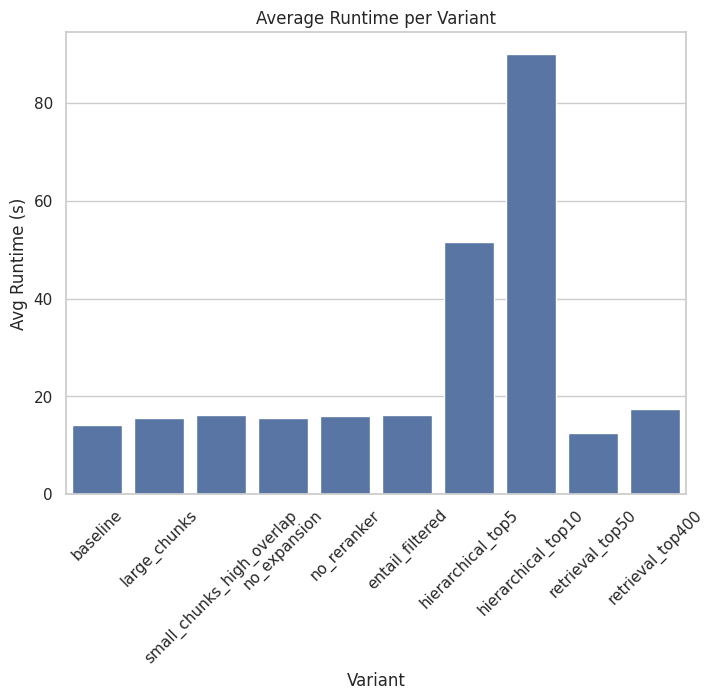

In [ ]:
df_runtime = df_summary[["Variant","Chunk Size","Overlap","Top K","Rerank K","Hierarchical Depth","Avg Runtime (s)"]]
df_runtime["Hierarchical Depth"] = df_runtime["Hierarchical Depth"].fillna("-")
display(df_runtime)
plt.figure(figsize=(8,6))
sns.barplot(x="Variant", y="Avg Runtime (s)", data=df_runtime)
plt.title("Average Runtime per Variant")
plt.xticks(rotation=45)
plt.show()


Normalizing metrics between 0 and 1. An overall composite score per variant is computed to combine multiple evaluation aspects into a single metric.

In [ ]:
df_summary_norm = df_summary.copy()
for metric in ["Sentence Grounding","ROUGE-1","Coverage"]:
    df_summary_norm[metric+"_norm"] = (df_summary_norm[metric]-df_summary_norm[metric].min()) / (df_summary_norm[metric].max()-df_summary_norm[metric].min()+1e-8)
df_summary_norm["Composite Score"] = df_summary_norm[["Sentence Grounding_norm","ROUGE-1_norm","Coverage_norm"]].mean(axis=1)


Visualizing the impact of chunk size and overlap on composite score.

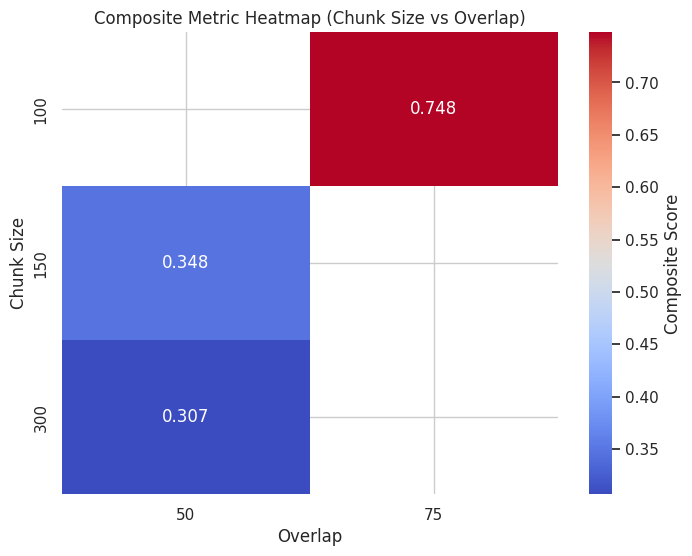

In [ ]:
pivot_composite = df_summary_norm.pivot_table(index="Chunk Size", columns="Overlap", values="Composite Score")
plt.figure(figsize=(8,6))
sns.heatmap(pivot_composite, annot=True, fmt=".3f", cmap="coolwarm", cbar_kws={'label':'Composite Score'})
plt.title("Composite Metric Heatmap (Chunk Size vs Overlap)")
plt.show()


Determining the configuration with the highest composite score.

In [ ]:
best_idx = df_summary_norm["Composite Score"].idxmax()
best_config = df_summary_norm.loc[best_idx]

print("\n===== Best Configuration Based on Composite Score =====")
print(best_config[["Variant","Chunk Size","Overlap","Top K","Rerank K","Use Expansion","Use Reranker","Hierarchical Depth","Composite Score"]])



===== Best Configuration Based on Composite Score =====
Variant               small_chunks_high_overlap
Chunk Size                                  100
Overlap                                      75
Top K                                       200
Rerank K                                     20
Use Expansion                              True
Use Reranker                               True
Hierarchical Depth                            -
Composite Score                        0.747916
Name: 2, dtype: object


Visualizing configuration with the highest composite score (red).

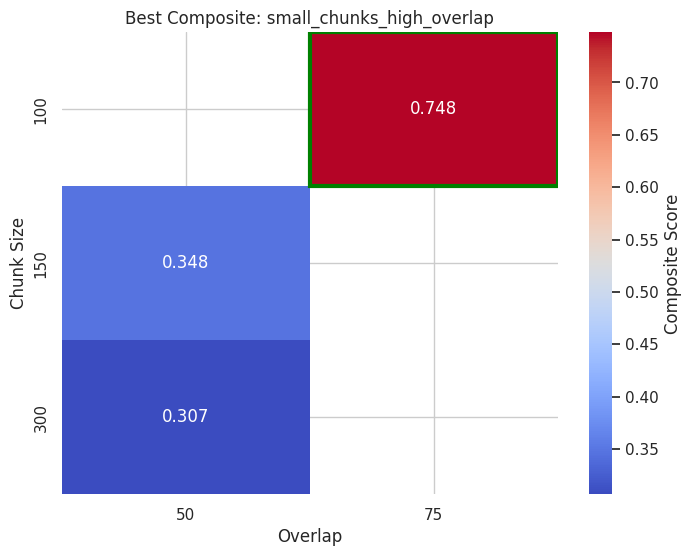

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(pivot_composite, annot=True, fmt=".3f", cmap="coolwarm", cbar_kws={'label':'Composite Score'})
ax = plt.gca()
i = list(pivot_composite.index).index(best_config["Chunk Size"])
j = list(pivot_composite.columns).index(best_config["Overlap"])
ax.add_patch(plt.Rectangle((j,i),1,1,fill=False,edgecolor='green',lw=3))
plt.title(f"Best Composite: {best_config['Variant']}")
plt.show()


Sorting all configurations by composite score for easier comparison and assigning a rank to each variant.

In [ ]:
ranking_df = df_summary_norm[["Variant","Chunk Size","Overlap","Top K","Rerank K","Hierarchical Depth","Composite Score"]].copy()
ranking_df = ranking_df.sort_values(by="Composite Score", ascending=False).reset_index(drop=True)
ranking_df["Rank"] = ranking_df.index + 1
ranking_df["Hierarchical Depth"] = ranking_df["Hierarchical Depth"].fillna("-")

print("\n===== Ranked Configurations by Composite Score =====")
display(ranking_df)




===== Ranked Configurations by Composite Score =====


,Variant,Chunk Size,Overlap,Top K,Rerank K,Hierarchical Depth,Composite Score,Rank
0,small_chunks_high_overlap,100,75,200,20,-,0.747916,1
1,no_reranker,150,50,200,20,-,0.598684,2
2,retrieval_top50,150,50,50,5,-,0.395281,3
3,retrieval_top400,150,50,400,40,-,0.389108,4
4,baseline,150,50,200,20,-,0.358874,5
5,hierarchical_top10,150,50,200,20,10.0,0.354746,6
6,entail_filtered,150,50,200,20,-,0.350576,7
7,large_chunks,300,50,200,20,-,0.307000,8
8,no_expansion,150,50,200,20,-,0.258475,9
9,hierarchical_top5,150,50,200,20,5.0,0.080466,10


Creating barplots to compare key metrics (Sentence Grounding, Entailment, Coverage, ROUGE-1, BERTScore F1) across variants, computing correlations between metrics to understand their relationships, plotting runtime versus composite score to assess efficiency versus quality trade-offs, and generating a heatmap to visualize the impact of retrieval depth (Top K) and reranking candidates (Rerank K) on overall performance.

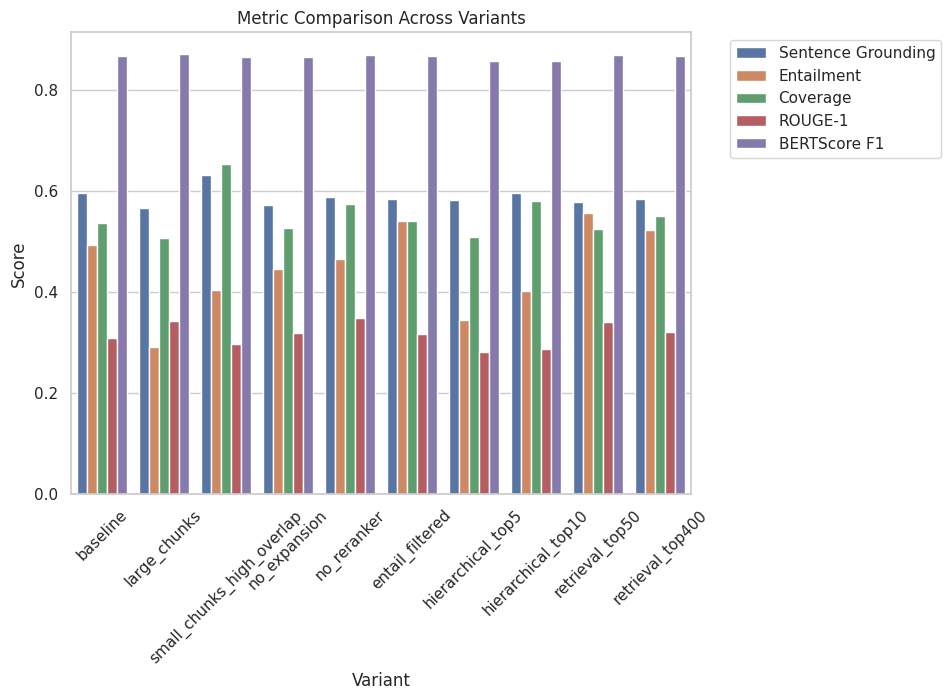

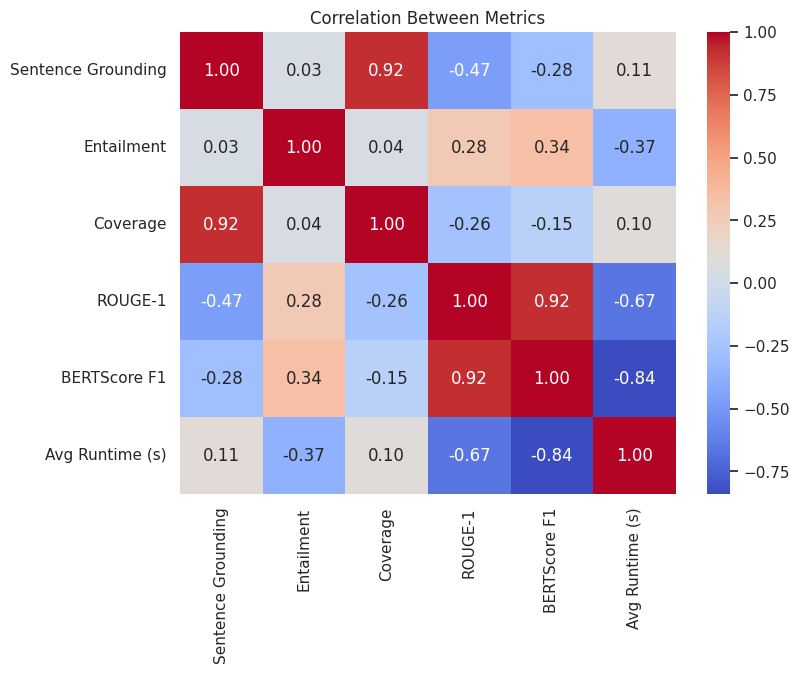

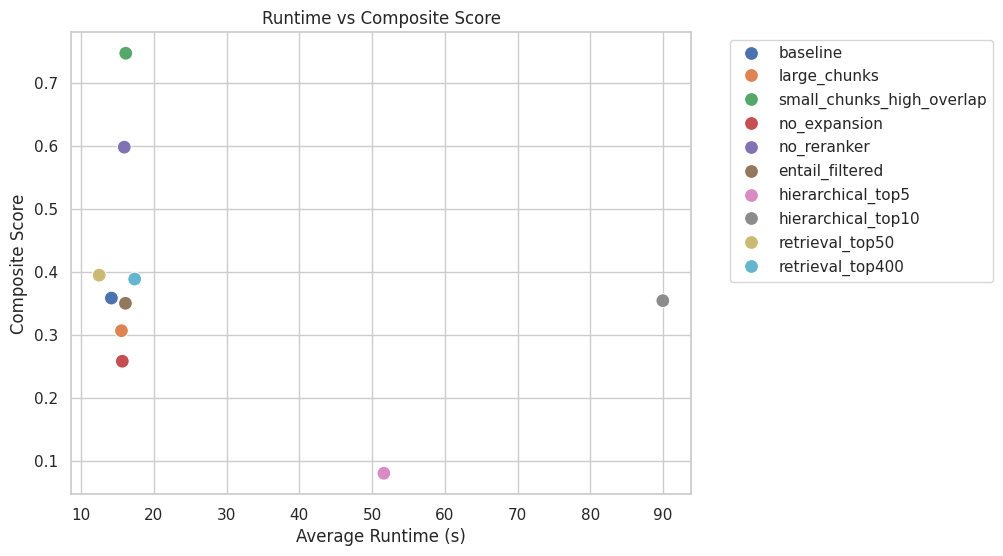

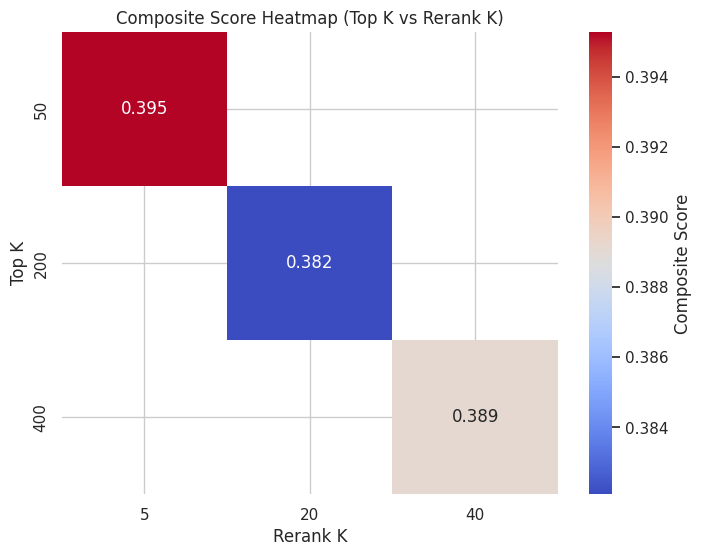

In [ ]:
metrics_to_plot = ["Sentence Grounding","Entailment","Coverage","ROUGE-1","BERTScore F1"]
df_plot = df_summary.melt(id_vars=["Variant"], value_vars=metrics_to_plot, var_name="Metric", value_name="Score")

plt.figure(figsize=(8,6))
sns.barplot(x="Variant", y="Score", hue="Metric", data=df_plot)
plt.xticks(rotation=45)
plt.title("Metric Comparison Across Variants")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df_summary[["Sentence Grounding","Entailment","Coverage","ROUGE-1","BERTScore F1","Avg Runtime (s)"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Metrics")
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(x="Avg Runtime (s)", y="Composite Score", hue="Variant", data=df_summary_norm, s=100)
plt.title("Runtime vs Composite Score")
plt.xlabel("Average Runtime (s)")
plt.ylabel("Composite Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

pivot_topk = df_summary_norm.pivot_table(index="Top K", columns="Rerank K", values="Composite Score")
plt.figure(figsize=(8,6))
sns.heatmap(pivot_topk, annot=True, fmt=".3f", cmap="coolwarm", cbar_kws={'label':'Composite Score'})
plt.title("Composite Score Heatmap (Top K vs Rerank K)")
plt.show()
